In [ ]:

# H4-1 (1표본 비율검정):
# - 변수: '몰랐음' 여부 (이진화)
# - 목적: 미방문자 중 '몰랐음' 비율이 50%를 넘는지 확인
# - 적합성 체크:
#   1) 이진 변수인가? -> 예 ('몰랐음'=1, 나머지=0)
#   2) 표본 수가 충분한가? -> n=74로 일반적으로 가능
#   3) 귀무가설 기준값(p0=0.5)이 해석상 타당한가? -> '과반수' 기준으로 직관적

# H4-2 (카이제곱 독립성 검정):
# - 변수1: 미방문 집단 유형 (몰라서 미방문 vs 알고도 미방문)
# - 변수2: 개선 필요 항목 (가격/접근성/혼잡/서비스부담)
# - 목적: 두 집단의 개선 니즈 프로파일이 다른지 확인
# - 적합성 체크:
#   1) 둘 다 범주형인가? -> 예
#   2) 기대빈도 5 미만 셀이 많은가? -> 가능성 있음 (알고도 미방문 n이 작음)
#      -> 필요시 카테고리 통합(예: 혼잡+서비스부담 합치기)
#   3) 표본 수가 작으면 결과 해석을 '탐색적'으로 표현
# =========================================

H4-1 검정: '인지/정보 부족' 집중 여부 (카이제곱 적합도 + 표준화 잔차)
미방문자 N = 74
카이제곱 적합도 검정: chi2 = 58.8378, p-value(고정) = 0.000000000005089, p-value(과학적) = 5.089435622314e-12

[관측도수/비율 + 표준화 잔차]


,이유(통합),관측도수,관측비율(%),기대도수(균등),표준화잔차
0,인지/정보 부족,39,52.7,14.8,6.29
1,관심/니즈 낮음,18,24.3,14.8,0.83
2,접근성,9,12.2,14.8,-1.51
3,가격,6,8.1,14.8,-2.29
4,기타 경험요인,2,2.7,14.8,-3.33



[해석(발표용 문장)]
- (1) 미방문 이유 분포는 균등하지 않습니다(p<0.05). → 특정 이유에 '쏠림'이 존재합니다.
- (2) 최빈 요인은 '인지/정보 부족'이며 비율은 52.7% 입니다.
- (3) 표준화 잔차가 6.29(≥2)로, '인지/정보 부족'이 기대(균등) 대비 유의하게 과대표집되었습니다.
    → 결론: H4-1(인지/정보 부족 요인에 집중)이 통계적으로 뒷받침됩니다.


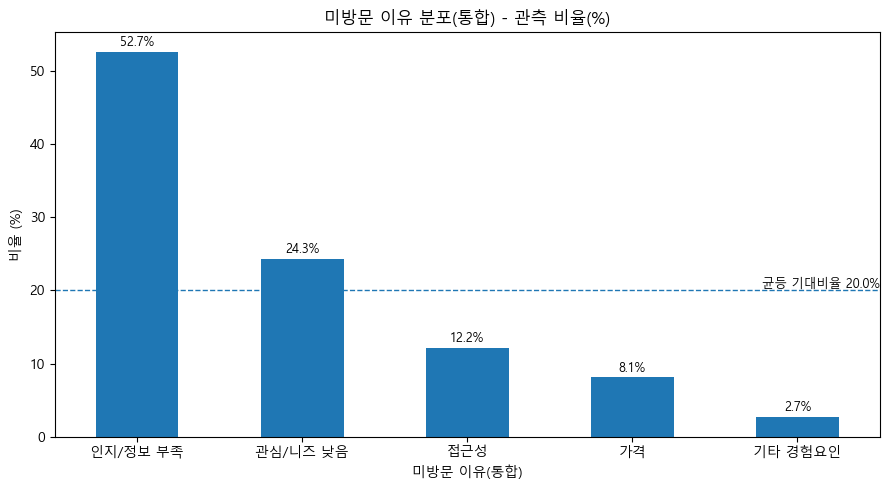

In [26]:
# =========================================
# H4-1. "리저브 미방문 장벽은 '인지/정보 부족'에 유의하게 집중된다" 검정
# - 발표에서는 파이차트로 분포(52.7%) 보여주고
# - 아래 검정으로 "쏠림이 통계적으로 유의함"을 뒷받침
#
# [검정 논리]
# 1) 카이제곱 적합도 검정(Goodness-of-fit)
#    H0: 미방문 이유 분포는 균등하다(=특정 이유에 쏠림 없음)
#    H1: 미방문 이유 분포는 균등하지 않다(=특정 이유에 쏠림 존재)
#
# 2) 표준화 잔차(Standardized residual)
#    - 어떤 이유가 "기대보다 유의하게 많이 나왔는지" 보여줌
#    - |잔차| >= 2 이면 흔히 '상대적으로 큰 차이'로 해석
#
# 결과 해석:
# - GOF p<0.05 => "분포가 균등하지 않음(쏠림 존재)" 확정
# - '인지/정보 부족' 잔차가 가장 크고 +2 이상이면
#   => "인지/정보 부족에 집중"이라고 말할 근거가 됨
# =========================================



# 2) 최소 전처리
for c in ["reserve_awareness_flag", "reserve_visited_flag", "reserve_nonvisit_reason"]:
    df[c] = df[c].astype(str).str.strip()
df = df.replace({"nan": np.nan, "": np.nan})

df["reserve_visited_flag"] = df["reserve_visited_flag"].replace({"Yes":"예","No":"아니오"})
df["reserve_awareness_flag"] = df["reserve_awareness_flag"].replace({"Yes":"예","No":"아니오"})

# 3) 미방문자만 추출 (74명)
nonvisit = df[df["reserve_visited_flag"] == "아니오"].copy()
n_nonvisit = len(nonvisit)

# 4) 미방문 이유 통합(카이제곱 검정 안정성 ↑)
reason_map = {
    "리저브 매장 존재여부 미인지(몰랐음)": "인지/정보 부족",
    "접근성 불편": "접근성",
    "가격 부담": "가격",
    "커피 취향/관심 낮음(단순 카페인 수혈 - 일반 매장으로 충분)": "관심/니즈 낮음",
    "매장 분위기/인테리어 불만족": "기타 경험요인"
}
nonvisit["nonvisit_reason_grouped"] = nonvisit["reserve_nonvisit_reason"].replace(reason_map)

# 5) 관측도수(Observed) 만들기
reason_order = ["인지/정보 부족", "관심/니즈 낮음", "접근성", "가격", "기타 경험요인"]
obs = nonvisit["nonvisit_reason_grouped"].value_counts().reindex(reason_order, fill_value=0)

# 6) 기대도수(Expected): "균등 분포" 가정 (각 이유가 동일 비율)
expected = np.repeat(obs.sum() / len(obs), len(obs))

# 7) 카이제곱 적합도 검정
chi2, p = chisquare(f_obs=obs.values, f_exp=expected)

# 8) 표준화 잔차(어느 이유가 쏠림을 만드는지)
std_resid = (obs.values - expected) / np.sqrt(expected)

result_df = pd.DataFrame({
    "이유(통합)": reason_order,
    "관측도수": obs.values,
    "관측비율(%)": (obs.values / obs.sum() * 100).round(1),
    "기대도수(균등)": expected.round(2),
    "표준화잔차": std_resid.round(2)
})

print("="*80)
print("H4-1 검정: '인지/정보 부족' 집중 여부 (카이제곱 적합도 + 표준화 잔차)")
print("="*80)
print(f"미방문자 N = {n_nonvisit}")
print(
    f"카이제곱 적합도 검정: chi2 = {chi2:.4f}, "
    f"p-value(고정) = {p:.15f}, "
    f"p-value(과학적) = {p:.12e}"
)
print("\n[관측도수/비율 + 표준화 잔차]")
display(result_df)

# 9) 자동 해석 문장 (발표용)
alpha = 0.05
top_reason = result_df.sort_values("관측도수", ascending=False).iloc[0]
top_name = top_reason["이유(통합)"]
top_pct = top_reason["관측비율(%)"]
top_resid = top_reason["표준화잔차"]

print("\n[해석(발표용 문장)]")
if p < alpha:
    print(f"- (1) 미방문 이유 분포는 균등하지 않습니다(p<{alpha}). → 특정 이유에 '쏠림'이 존재합니다.")
else:
    print(f"- (1) 미방문 이유 분포가 균등하지 않다고 말하기 어렵습니다(p≥{alpha}).")

print(f"- (2) 최빈 요인은 '{top_name}'이며 비율은 {top_pct:.1f}% 입니다.")
if (top_name == "인지/정보 부족") and (top_resid >= 2):
    print(f"- (3) 표준화 잔차가 {top_resid:.2f}(≥2)로, '인지/정보 부족'이 기대(균등) 대비 유의하게 과대표집되었습니다.")
    print("    → 결론: H4-1(인지/정보 부족 요인에 집중)이 통계적으로 뒷받침됩니다.")
elif top_name == "인지/정보 부족":
    print(f"- (3) 표준화 잔차는 {top_resid:.2f}로, 기대 대비 '더 많이' 나타나긴 했으나 강한 수준(≥2)인지 확인이 필요합니다.")
    print("    → 결론: '인지/정보 부족'이 가장 큰 장벽이라는 점은 EDA로 확인되며, '유의한 집중'은 GOF p값/잔차를 함께 해석합니다.")
else:
    print(f"- (3) 가장 큰 요인은 '{top_name}'이며, '인지/정보 부족'이 최빈이 아닙니다. (가설 재점검 필요)")

# 10) (선택) 시각화: 관측 vs 균등 기대 라인
ax = (obs / obs.sum() * 100).plot(kind="bar", figsize=(9,5), rot=0)
plt.title("미방문 이유 분포(통합) - 관측 비율(%)")
plt.xlabel("미방문 이유(통합)")
plt.ylabel("비율 (%)")

# 기대비율(균등) 라인
expected_pct = 100 / len(reason_order)
plt.axhline(expected_pct, linestyle="--", linewidth=1)
plt.text(len(reason_order)-0.5, expected_pct, f"균등 기대비율 {expected_pct:.1f}%", va="bottom", ha="right", fontsize=9)

for p_ in ax.patches:
    h = p_.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p_.get_x() + p_.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9,
                    xytext=(0,2), textcoords="offset points")

plt.tight_layout()
plt.show()

In [50]:
N = int(obs.sum())
df_gof = len(obs) - 1
w = np.sqrt(chi2 / N)

# '인지/정보 부족'이 reason_order의 첫 번째라면:
resid_awareness = float(std_resid[0])

print("N:", N)
print("df:", df_gof)
print("chi2:", chi2)
print("p:", p)
print("Cohen's w:", w)
print("Std resid(인지/정보 부족):", resid_awareness)

N: 74
df: 4
chi2: 58.83783783783784
p: 5.089435622313602e-12
Cohen's w: 0.8916871181796552
Std resid(인지/정보 부족): 6.290490463411439


In [40]:
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# --- 효과크기: Cohen's w (GOF) ---
N = int(obs.sum())
w = np.sqrt(chi2 / N)

def interpret_w(w):
    if w < 0.10:
        return "매우 작음(≈negligible)"
    elif w < 0.30:
        return "작음(small)"
    elif w < 0.50:
        return "중간(medium)"
    else:
        return "큼(large)"

print("\n[효과크기] Cohen's w (GOF)")
print(f"w = sqrt(chi2/N) = sqrt({chi2:.4f}/{N}) = {w:.3f} → {interpret_w(w)}")

# --- (보너스) '인지/정보 부족' 비율 95% CI (발표용 직관 강화) ---
x = int(obs.loc["인지/정보 부족"])
p_hat = x / N

ci_low, ci_high = proportion_confint(count=x, nobs=N, alpha=0.05, method="wilson")
print("\n['인지/정보 부족' 비율 95% CI (Wilson)]")
print(f"{x}/{N} = {p_hat*100:.1f}% (95% CI: {ci_low*100:.1f}% ~ {ci_high*100:.1f}%)")


[효과크기] Cohen's w (GOF)
w = sqrt(chi2/N) = sqrt(58.8378/74) = 0.892 → 큼(large)

['인지/정보 부족' 비율 95% CI (Wilson)]
39/74 = 52.7% (95% CI: 41.5% ~ 63.7%)


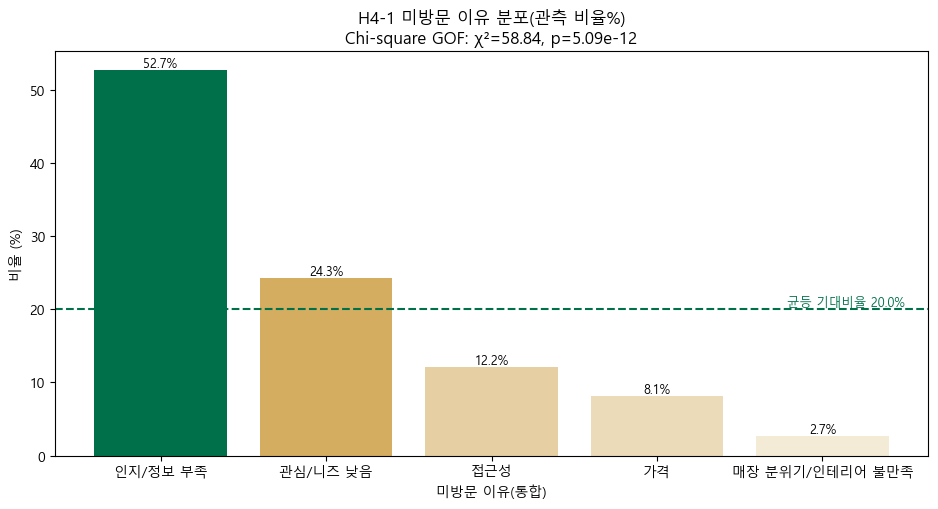

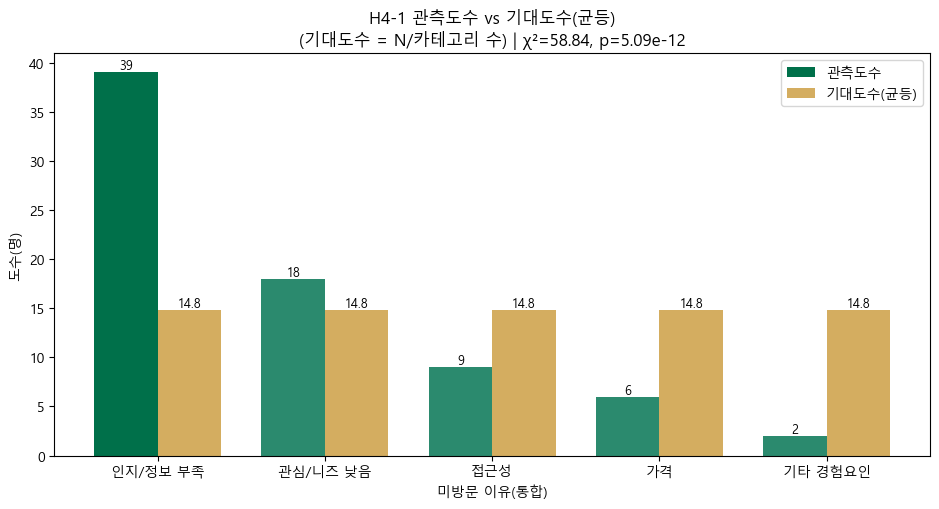

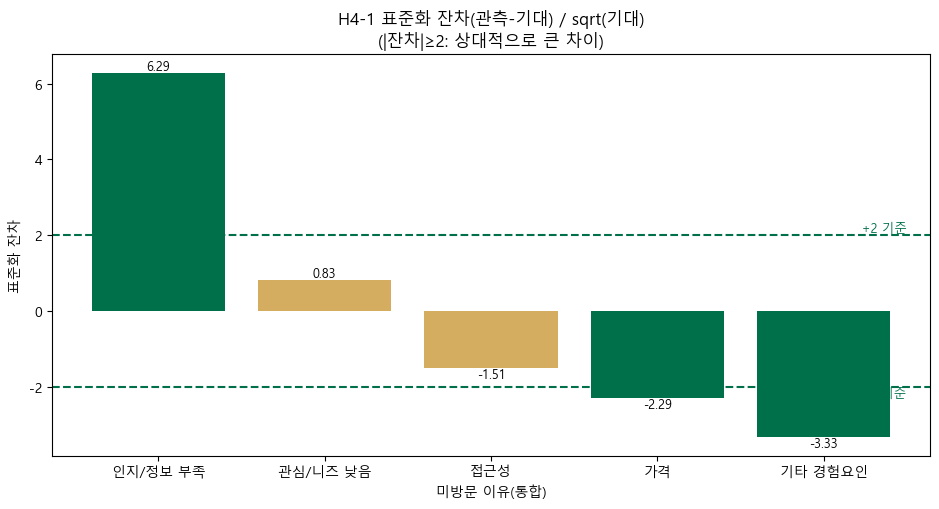

In [43]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

STARBUCKS_GREEN = "#00704A"
STARBUCKS_GOLD  = "#D4AD60"

def blend_with_white(hex_color, t):
    """
    t: 0~1
    - 0이면 거의 흰색(아주 연함)
    - 1이면 원래 색(진함)
    """
    rgb = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1, 1, 1])
    out = white * (1 - t) + rgb * t
    return out


# --- 시각화용 DF ---
viz_df = pd.DataFrame({
    "이유": reason_order,
    "관측도수": obs.values,
    "기대도수(균등)": np.array(expected),
    "관측비율(%)": (obs.values / obs.sum() * 100),
    "표준화잔차": np.array(std_resid)
})

# 색: '인지/정보 부족'만 초록, 나머지 금색
bar_colors = [STARBUCKS_GREEN if r == "인지/정보 부족" else STARBUCKS_GOLD for r in viz_df["이유"]]

p_txt = f"p={float(p):.2e}"

# =========================================
# (그래프 1) 관측 비율(%) + 균등 기대선(20%)
# =========================================
# =========================================
# (그래프 1) 관측 비율(%) + 균등 기대선(20%)
# - 최고 비율 1개: 초록
# - 나머지: 골드/베이지 계열을 비율에 따라 진→연 그라데이션
# =========================================
vals = viz_df["관측비율(%)"].values
labels = viz_df["이유"].replace({"기타 경험요인": "매장 분위기/인테리어 불만족"}).values

imax = int(np.argmax(vals))
other_idx = [i for i in range(len(vals)) if i != imax]
other_vals = vals[other_idx]

# 나머지 값들을 0~1로 정규화
vmin, vmax = other_vals.min(), other_vals.max()
if vmax == vmin:
    norm = np.ones_like(vals)  # 모두 같으면 동일 톤
else:
    norm = (vals - vmin) / (vmax - vmin)

bar_colors = []
for i, v in enumerate(vals):
    if i == imax:
        bar_colors.append(STARBUCKS_GREEN)
    else:
        # t 범위 조절: 너무 하얘지지 않게(0.25~1.0)
        t = 0.25 + 0.75 * float(norm[i])
        bar_colors.append(blend_with_white(STARBUCKS_GOLD, t))

p_txt = f"p={float(p):.2e}"

plt.figure(figsize=(9.5, 5.2))
ax = plt.bar(labels, vals, color=bar_colors)

plt.title(f"H4-1 미방문 이유 분포(관측 비율%)\nChi-square GOF: χ²={chi2:.2f}, {p_txt}")
plt.xlabel("미방문 이유(통합)")
plt.ylabel("비율 (%)")

expected_pct = 100 / len(reason_order)
plt.axhline(expected_pct, linestyle="--", linewidth=1.5, color=STARBUCKS_GREEN)
plt.text(len(reason_order)-0.5, expected_pct, f"균등 기대비율 {expected_pct:.1f}%",
         ha="right", va="bottom", fontsize=9, color=STARBUCKS_GREEN)

for i, v in enumerate(vals):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# =========================================
# (그래프 2) 관측도수 vs 기대도수(균등) 쌍막대
# =========================================
plt.figure(figsize=(9.5, 5.2))
x = np.arange(len(reason_order))
width = 0.38

# 관측: 초록(핵심항목만 더 진하게), 기대: 금색(연한 톤)
obs_colors = [STARBUCKS_GREEN if r == "인지/정보 부족" else "#2b8a6e" for r in reason_order]  # 초록 계열 변주
exp_colors = [STARBUCKS_GOLD for _ in reason_order]

plt.bar(x - width/2, viz_df["관측도수"], width, label="관측도수", color=obs_colors)
plt.bar(x + width/2, viz_df["기대도수(균등)"], width, label="기대도수(균등)", color=exp_colors)

plt.title(f"H4-1 관측도수 vs 기대도수(균등)\n(기대도수 = N/카테고리 수) | χ²={chi2:.2f}, {p_txt}")
plt.xticks(x, reason_order)
plt.xlabel("미방문 이유(통합)")
plt.ylabel("도수(명)")
plt.legend(loc="upper right")

# 도수 라벨
for i, (o, e) in enumerate(zip(viz_df["관측도수"].values, viz_df["기대도수(균등)"].values)):
    plt.text(i - width/2, o, f"{int(o)}", ha="center", va="bottom", fontsize=9)
    plt.text(i + width/2, e, f"{e:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# =========================================
# (그래프 3) 표준화 잔차 + 기준선(±2)
# =========================================
plt.figure(figsize=(9.5, 5.2))

# 잔차 색: 절댓값이 큰 애(>=2) 강조(초록), 그 외 금색
resid_colors = [STARBUCKS_GREEN if abs(r) >= 2 else STARBUCKS_GOLD for r in viz_df["표준화잔차"]]
plt.bar(viz_df["이유"], viz_df["표준화잔차"], color=resid_colors)

plt.title("H4-1 표준화 잔차(관측-기대) / sqrt(기대)\n(|잔차|≥2: 상대적으로 큰 차이)")
plt.xlabel("미방문 이유(통합)")
plt.ylabel("표준화 잔차")

# 기준선(±2)
plt.axhline(2, linestyle="--", linewidth=1.5, color=STARBUCKS_GREEN)
plt.axhline(-2, linestyle="--", linewidth=1.5, color=STARBUCKS_GREEN)
plt.text(len(reason_order)-0.5, 2, "  +2 기준", ha="right", va="bottom", fontsize=9, color=STARBUCKS_GREEN)
plt.text(len(reason_order)-0.5, -2, "  -2 기준", ha="right", va="top", fontsize=9, color=STARBUCKS_GREEN)

# 잔차 라벨
for i, r in enumerate(viz_df["표준화잔차"].values):
    plt.text(i, r, f"{r:.2f}", ha="center", va="bottom" if r>=0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

[검문소] 미방문자 수: 74명
reserve_awareness_flag
아니오    55
예      19
Name: count, dtype: int64
reserve_nonvisit_reason
리저브 매장 존재여부 미인지(몰랐음)                   39
커피 취향/관심 낮음(단순 카페인 수혈 - 일반 매장으로 충분)    18
접근성 불편                                  9
가격 부담                                   6
매장 분위기/인테리어 불만족                         2
Name: count, dtype: int64
H4-1 검정: '인지/정보 부족' 집중 여부 (카이제곱 적합도 + 표준화 잔차)
미방문자 N = 74
카이제곱 적합도 검정: chi2 = 58.8378, p-value(고정) = 0.000000000005089, p-value(과학적) = 5.089435622314e-12

[관측도수/비율 + 표준화 잔차]


,이유(통합),관측도수,관측비율(%),기대도수(균등),표준화잔차
0,인지/정보 부족,39,52.7,14.8,6.29
1,관심/니즈 낮음,18,24.3,14.8,0.83
2,접근성,9,12.2,14.8,-1.51
3,가격,6,8.1,14.8,-2.29
4,기타 경험요인,2,2.7,14.8,-3.33



[해석(발표용 문장)]
- (1) 미방문 이유 분포는 균등하지 않습니다(p<0.05). → 특정 이유에 '쏠림'이 존재합니다.
- (2) 최빈 요인은 '인지/정보 부족'이며 비율은 52.7% 입니다.
- (3) 표준화 잔차가 6.29(≥2)로, '인지/정보 부족'이 기대(균등) 대비 유의하게 과대표집되었습니다.
    → 결론: H4-1(인지/정보 부족 요인에 집중)이 통계적으로 뒷받침됩니다.


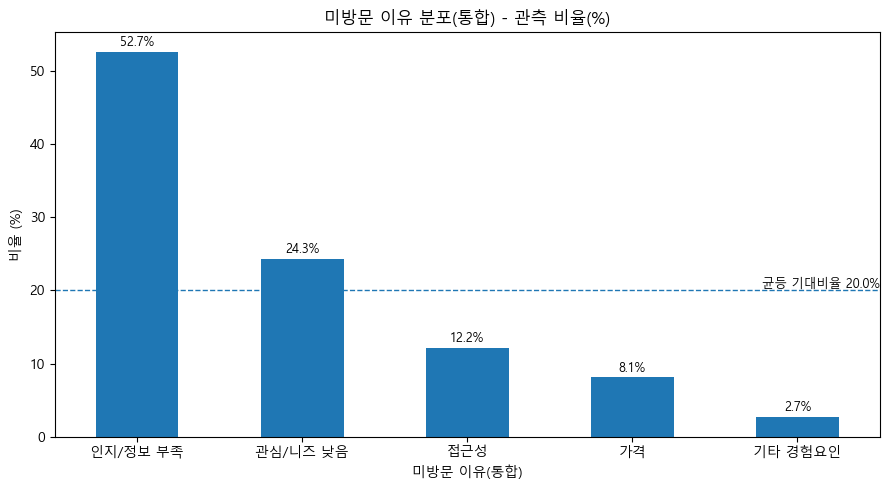


[H4-2] 교차표 (4개 개선항목)
improve_grouped  접근성 개선  가격 개선  혼잡/대기 개선  서비스 부담 완화
h4_group                                           
몰라서 미방문              31     19         2          3
알고도 미방문               8      9         0          2

[H4-2 결과 - 4개 카테고리]
chi2 = 2.3869
p-value = 0.496072
dof = 3
기대빈도 최소값 = 0.514

[H4-2] 교차표 (3개 통합항목, 권장)
improve_grouped_3  접근성 개선  가격 개선  이용경험 개선
h4_group                                 
몰라서 미방문                31     19        5
알고도 미방문                 8      9        2

[H4-2 결과 - 3개 통합항목]
chi2 = 1.1892
p-value = 0.551791
dof = 2
기대빈도 최소값 = 1.797

[H4-2 해석용] 집단 내 개선항목 비율(%)


improve_grouped_3,접근성 개선,가격 개선,이용경험 개선
h4_group,,,
몰라서 미방문,56.4,34.5,9.1
알고도 미방문,42.1,47.4,10.5


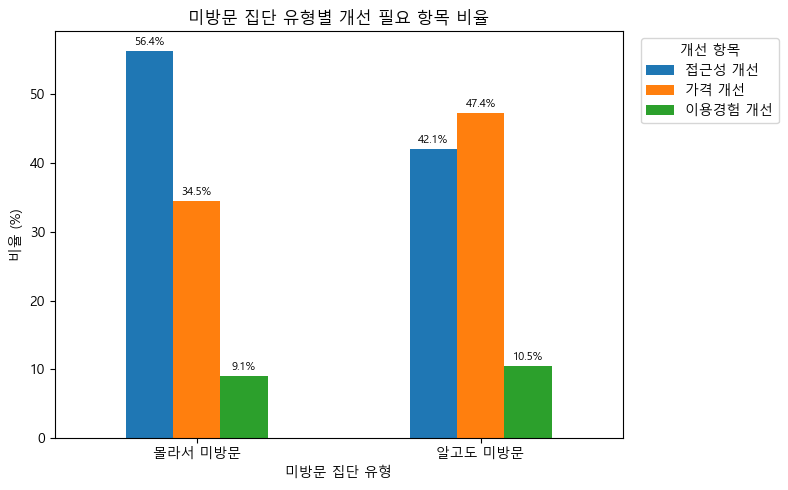

In [23]:
# =========================================
# H4. 가설 분석
# =========================================

import pandas as pd
import numpy as np
from scipy.stats import chisquare, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import platform

# 한글 폰트 (그래프용)
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------------------
# 0. 데이터 로드 (전처리 저장본 권장)
# -----------------------------------------
# h4_path = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_h4_refined.csv"
# df = pd.read_csv(h4_path)

# 업로드 원본 기준(전처리 최소 재구성)
df = pd.read_csv(
    r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_response.csv",
    encoding="utf-8-sig"
)
# 최소 전처리 재실행 (노트북 독립성 확보)
for c in ["reserve_awareness_flag", "reserve_visited_flag", "reserve_nonvisit_reason", "reserve_improvement"]:
    df[c] = df[c].astype(str).str.strip()
df = df.replace({"nan": np.nan})

df["reserve_awareness_flag"] = df["reserve_awareness_flag"].replace({"Yes":"예","No":"아니오"})
df["reserve_visited_flag"] = df["reserve_visited_flag"].replace({"Yes":"예","No":"아니오"})

reason_map = {
    "리저브 매장 존재여부 미인지(몰랐음)": "인지/정보 부족",
    "접근성 불편": "접근성",
    "가격 부담": "가격",
    "커피 취향/관심 낮음(단순 카페인 수혈 - 일반 매장으로 충분)": "관심/니즈 낮음",
    "매장 분위기/인테리어 불만족": "기타 경험요인"
}
df["nonvisit_reason_grouped"] = df["reserve_nonvisit_reason"].replace(reason_map)

improve_map = {
    "매장 접근성 개선(추가 매장 확대)": "접근성 개선",
    "가격 인하": "가격 개선",
    "혼잡 및 대기 개선(예약/대기 시스템)": "혼잡/대기 개선",
    "리저브 바(Bar) 1:1 서비스 부담 완화": "서비스 부담 완화"
}
df["improve_grouped"] = df["reserve_improvement"].replace(improve_map)

# H4 분석 대상: 미방문자
nonvisit = df[df["reserve_visited_flag"] == "아니오"].copy()
n_nonvisit = len(nonvisit)

print(f"[검문소] 미방문자 수: {n_nonvisit}명")
print(nonvisit["reserve_awareness_flag"].value_counts(dropna=False))
print(nonvisit["reserve_nonvisit_reason"].value_counts(dropna=False))


# =========================================
# H4-1. "리저브 미방문 장벽은 '인지/정보 부족'에 유의하게 집중된다" 검정
# - 발표에서는 파이차트로 분포(52.7%) 보여주고
# - 아래 검정으로 "쏠림이 통계적으로 유의함"을 뒷받침
#
# [검정 논리]
# 1) 카이제곱 적합도 검정(Goodness-of-fit)
#    H0: 미방문 이유 분포는 균등하다(=특정 이유에 쏠림 없음)
#    H1: 미방문 이유 분포는 균등하지 않다(=특정 이유에 쏠림 존재)
#
# 2) 표준화 잔차(Standardized residual)
#    - 어떤 이유가 "기대보다 유의하게 많이 나왔는지" 보여줌
#    - |잔차| >= 2 이면 흔히 '상대적으로 큰 차이'로 해석
#
# 결과 해석:
# - GOF p<0.05 => "분포가 균등하지 않음(쏠림 존재)" 확정
# - '인지/정보 부족' 잔차가 가장 크고 +2 이상이면
#   => "인지/정보 부족에 집중"이라고 말할 근거가 됨
# =========================================



# 2) 최소 전처리
for c in ["reserve_awareness_flag", "reserve_visited_flag", "reserve_nonvisit_reason"]:
    df[c] = df[c].astype(str).str.strip()
df = df.replace({"nan": np.nan, "": np.nan})

df["reserve_visited_flag"] = df["reserve_visited_flag"].replace({"Yes":"예","No":"아니오"})
df["reserve_awareness_flag"] = df["reserve_awareness_flag"].replace({"Yes":"예","No":"아니오"})

# 3) 미방문자만 추출 (74명)
nonvisit = df[df["reserve_visited_flag"] == "아니오"].copy()
n_nonvisit = len(nonvisit)

# 4) 미방문 이유 통합(카이제곱 검정 안정성 ↑)
reason_map = {
    "리저브 매장 존재여부 미인지(몰랐음)": "인지/정보 부족",
    "접근성 불편": "접근성",
    "가격 부담": "가격",
    "커피 취향/관심 낮음(단순 카페인 수혈 - 일반 매장으로 충분)": "관심/니즈 낮음",
    "매장 분위기/인테리어 불만족": "기타 경험요인"
}
nonvisit["nonvisit_reason_grouped"] = nonvisit["reserve_nonvisit_reason"].replace(reason_map)

# 5) 관측도수(Observed) 만들기
reason_order = ["인지/정보 부족", "관심/니즈 낮음", "접근성", "가격", "기타 경험요인"]
obs = nonvisit["nonvisit_reason_grouped"].value_counts().reindex(reason_order, fill_value=0)

# 6) 기대도수(Expected): "균등 분포" 가정 (각 이유가 동일 비율)
expected = np.repeat(obs.sum() / len(obs), len(obs))

# 7) 카이제곱 적합도 검정
chi2, p = chisquare(f_obs=obs.values, f_exp=expected)

# 8) 표준화 잔차(어느 이유가 쏠림을 만드는지)
std_resid = (obs.values - expected) / np.sqrt(expected)

result_df = pd.DataFrame({
    "이유(통합)": reason_order,
    "관측도수": obs.values,
    "관측비율(%)": (obs.values / obs.sum() * 100).round(1),
    "기대도수(균등)": expected.round(2),
    "표준화잔차": std_resid.round(2)
})

print("="*80)
print("H4-1 검정: '인지/정보 부족' 집중 여부 (카이제곱 적합도 + 표준화 잔차)")
print("="*80)
print(f"미방문자 N = {n_nonvisit}")
print(
    f"카이제곱 적합도 검정: chi2 = {chi2:.4f}, "
    f"p-value(고정) = {p:.15f}, "
    f"p-value(과학적) = {p:.12e}"
)
print("\n[관측도수/비율 + 표준화 잔차]")
display(result_df)

# 9) 자동 해석 문장 (발표용)
alpha = 0.05
top_reason = result_df.sort_values("관측도수", ascending=False).iloc[0]
top_name = top_reason["이유(통합)"]
top_pct = top_reason["관측비율(%)"]
top_resid = top_reason["표준화잔차"]

print("\n[해석(발표용 문장)]")
if p < alpha:
    print(f"- (1) 미방문 이유 분포는 균등하지 않습니다(p<{alpha}). → 특정 이유에 '쏠림'이 존재합니다.")
else:
    print(f"- (1) 미방문 이유 분포가 균등하지 않다고 말하기 어렵습니다(p≥{alpha}).")

print(f"- (2) 최빈 요인은 '{top_name}'이며 비율은 {top_pct:.1f}% 입니다.")
if (top_name == "인지/정보 부족") and (top_resid >= 2):
    print(f"- (3) 표준화 잔차가 {top_resid:.2f}(≥2)로, '인지/정보 부족'이 기대(균등) 대비 유의하게 과대표집되었습니다.")
    print("    → 결론: H4-1(인지/정보 부족 요인에 집중)이 통계적으로 뒷받침됩니다.")
elif top_name == "인지/정보 부족":
    print(f"- (3) 표준화 잔차는 {top_resid:.2f}로, 기대 대비 '더 많이' 나타나긴 했으나 강한 수준(≥2)인지 확인이 필요합니다.")
    print("    → 결론: '인지/정보 부족'이 가장 큰 장벽이라는 점은 EDA로 확인되며, '유의한 집중'은 GOF p값/잔차를 함께 해석합니다.")
else:
    print(f"- (3) 가장 큰 요인은 '{top_name}'이며, '인지/정보 부족'이 최빈이 아닙니다. (가설 재점검 필요)")

# 10) (선택) 시각화: 관측 vs 균등 기대 라인
ax = (obs / obs.sum() * 100).plot(kind="bar", figsize=(9,5), rot=0)
plt.title("미방문 이유 분포(통합) - 관측 비율(%)")
plt.xlabel("미방문 이유(통합)")
plt.ylabel("비율 (%)")

# 기대비율(균등) 라인
expected_pct = 100 / len(reason_order)
plt.axhline(expected_pct, linestyle="--", linewidth=1)
plt.text(len(reason_order)-0.5, expected_pct, f"균등 기대비율 {expected_pct:.1f}%", va="bottom", ha="right", fontsize=9)

for p_ in ax.patches:
    h = p_.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p_.get_x() + p_.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9,
                    xytext=(0,2), textcoords="offset points")

plt.tight_layout()
plt.show()

# =========================================
# H4-2. 카이제곱 독립성 검정 (알고도 미방문 vs 몰라서 미방문 × 개선 필요 항목)
# =========================================
# 그룹 생성
nonvisit["h4_group"] = np.select(
    [
        (nonvisit["reserve_awareness_flag"] == "아니오"),
        (nonvisit["reserve_awareness_flag"] == "예")
    ],
    [
        "몰라서 미방문",
        "알고도 미방문"
    ],
    default="기타"
)

# 분석 대상 2집단만
sub = nonvisit[nonvisit["h4_group"].isin(["몰라서 미방문", "알고도 미방문"])].copy()

# 개선항목 결측 제거
sub = sub.dropna(subset=["improve_grouped"]).copy()

# (선택) 기대빈도 문제 줄이기 위해 카테고리 통합 버전도 준비
# 예: '혼잡/대기 개선' + '서비스 부담 완화' -> '서비스 이용 경험 개선'
sub["improve_grouped_3"] = sub["improve_grouped"].replace({
    "혼잡/대기 개선": "이용경험 개선",
    "서비스 부담 완화": "이용경험 개선"
})

# --- 4개 카테고리 버전 ---
ct4 = pd.crosstab(sub["h4_group"], sub["improve_grouped"]).reindex(
    index=["몰라서 미방문", "알고도 미방문"],
    columns=["접근성 개선", "가격 개선", "혼잡/대기 개선", "서비스 부담 완화"],
    fill_value=0
)

print("\n[H4-2] 교차표 (4개 개선항목)")
print(ct4)

chi2_4, p_4, dof_4, expected_4 = chi2_contingency(ct4)
exp4_df = pd.DataFrame(expected_4, index=ct4.index, columns=ct4.columns)

print("\n[H4-2 결과 - 4개 카테고리]")
print(f"chi2 = {chi2_4:.4f}")
print(f"p-value = {p_4:.6f}")
print(f"dof = {dof_4}")
print(f"기대빈도 최소값 = {exp4_df.min().min():.3f}")

# 기대빈도 작으면 참고용(탐색적)으로 해석하고, 3개 통합버전 병행 권장

# --- 3개 통합 카테고리 버전 (권장 해석용) ---
ct3 = pd.crosstab(sub["h4_group"], sub["improve_grouped_3"]).reindex(
    index=["몰라서 미방문", "알고도 미방문"],
    columns=["접근성 개선", "가격 개선", "이용경험 개선"],
    fill_value=0
)

print("\n[H4-2] 교차표 (3개 통합항목, 권장)")
print(ct3)

chi2_3, p_3, dof_3, expected_3 = chi2_contingency(ct3)
exp3_df = pd.DataFrame(expected_3, index=ct3.index, columns=ct3.columns)

print("\n[H4-2 결과 - 3개 통합항목]")
print(f"chi2 = {chi2_3:.4f}")
print(f"p-value = {p_3:.6f}")
print(f"dof = {dof_3}")
print(f"기대빈도 최소값 = {exp3_df.min().min():.3f}")

# 행비율(집단 내 비중) 표도 같이 보면 해석이 쉬움
ct3_pct = ct3.div(ct3.sum(axis=1), axis=0) * 100
print("\n[H4-2 해석용] 집단 내 개선항목 비율(%)")
display(ct3_pct.round(1))

# =========================================
# (선택) 시각화: H4-2 집단별 개선항목 비율 비교
# =========================================
ax = ct3_pct.plot(kind="bar", figsize=(8,5), rot=0)
plt.title("미방문 집단 유형별 개선 필요 항목 비율")
plt.xlabel("미방문 집단 유형")
plt.ylabel("비율 (%)")
plt.legend(title="개선 항목", bbox_to_anchor=(1.02, 1), loc="upper left")

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0,2), textcoords="offset points")

plt.tight_layout()
plt.show()

In [4]:
# =========================================
# H4-2 공통 준비 셀
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

from scipy.stats import chi2_contingency

# 한글 폰트
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv(
    r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_response.csv",
    encoding="utf-8-sig"
)

# Yes/No 통일 + 공백 제거
df["reserve_visited_flag"] = df["reserve_visited_flag"].astype(str).str.strip().replace({"Yes":"예","No":"아니오"})
df["reserve_awareness_flag"] = df["reserve_awareness_flag"].astype(str).str.strip().replace({"Yes":"예","No":"아니오"})

# 결측 문자열 처리
df = df.replace({"nan": np.nan, "": np.nan})

# 미방문자만
nonvisit = df[df["reserve_visited_flag"] == "아니오"].copy()
print("미방문자 수:", len(nonvisit))

# 개선항목 통합 라벨(분석용)
improve_map = {
    "매장 접근성 개선(추가 매장 확대)": "접근성 개선",
    "가격 인하": "가격 개선",
    "혼잡 및 대기 개선(예약/대기 시스템)": "혼잡/대기 개선",
    "리저브 바(Bar) 1:1 서비스 부담 완화": "서비스 부담 완화"
}
nonvisit["improve_grouped"] = nonvisit["reserve_improvement"].astype(str).str.strip().replace(improve_map)

# 미방문 이유(불일치 판별용)
nonvisit["nonvisit_reason"] = nonvisit["reserve_nonvisit_reason"].astype(str).str.strip()

# 불일치 케이스: 인지는 '예'인데 이유가 '몰랐음'
inconsistent_mask = (
    (nonvisit["reserve_awareness_flag"] == "예") &
    (nonvisit["nonvisit_reason"] == "리저브 매장 존재여부 미인지(몰랐음)")
)

print("⚠️ 응답 불일치(인지=예 & 이유=몰랐음) 건수:", inconsistent_mask.sum())

미방문자 수: 74
⚠️ 응답 불일치(인지=예 & 이유=몰랐음) 건수: 2


In [6]:
import numpy as np
import pandas as pd

def make_h4_groups(nonvisit_df, mode="exclude_inconsistent"):
    """
    mode 옵션:
    1) 'exclude_inconsistent'        : 불일치 2건 제외 (권장, 가장 엄밀)
    2) 'tag_inconsistent'            : 불일치 2건을 '불일치' 라벨로 두고, 필요시 분석에서 제외
    3) 'reason_overrides_awareness'  : 이유가 '몰랐음'이면 '몰라서 미방문'으로 재분류
    """

    d = nonvisit_df.copy()

    # ✅ 컬럼명 안전 처리: 네 데이터에 있는 쪽으로 자동 선택
    reason_col = "reserve_nonvisit_reason" if "reserve_nonvisit_reason" in d.columns else "nonvisit_reason"

    inconsistent = (
        (d["reserve_awareness_flag"] == "예") &
        (d[reason_col] == "리저브 매장 존재여부 미인지(몰랐음)")
    )

    if mode == "exclude_inconsistent":
        d = d.loc[~inconsistent].copy()

    # ✅ np.select default를 문자열로 (dtype 충돌 방지)
    d["h4_group"] = np.select(
        [
            (d["reserve_awareness_flag"] == "아니오"),
            (d["reserve_awareness_flag"] == "예")
        ],
        ["몰라서 미방문", "알고도 미방문"],
        default="미정"   # <- np.nan 말고 문자열로!
    ).astype("object")

    if mode == "tag_inconsistent":
        d.loc[inconsistent, "h4_group"] = "불일치"

    if mode == "reason_overrides_awareness":
        d.loc[d[reason_col] == "리저브 매장 존재여부 미인지(몰랐음)", "h4_group"] = "몰라서 미방문"

    return d

# 3개 버전 데이터 만들기
nv_A = make_h4_groups(nonvisit, mode="exclude_inconsistent")
nv_B = make_h4_groups(nonvisit, mode="tag_inconsistent")
nv_C = make_h4_groups(nonvisit, mode="reason_overrides_awareness")

print("[A] 불일치 제외 후 그룹 분포")
print(nv_A["h4_group"].value_counts(dropna=False))

print("\n[B] 불일치 태그 포함 그룹 분포")
print(nv_B["h4_group"].value_counts(dropna=False))

print("\n[C] 이유 우선 재분류 그룹 분포")
print(nv_C["h4_group"].value_counts(dropna=False))

[A] 불일치 제외 후 그룹 분포
h4_group
몰라서 미방문    55
알고도 미방문    17
Name: count, dtype: int64

[B] 불일치 태그 포함 그룹 분포
h4_group
몰라서 미방문    55
알고도 미방문    17
불일치         2
Name: count, dtype: int64

[C] 이유 우선 재분류 그룹 분포
h4_group
몰라서 미방문    57
알고도 미방문    17
Name: count, dtype: int64


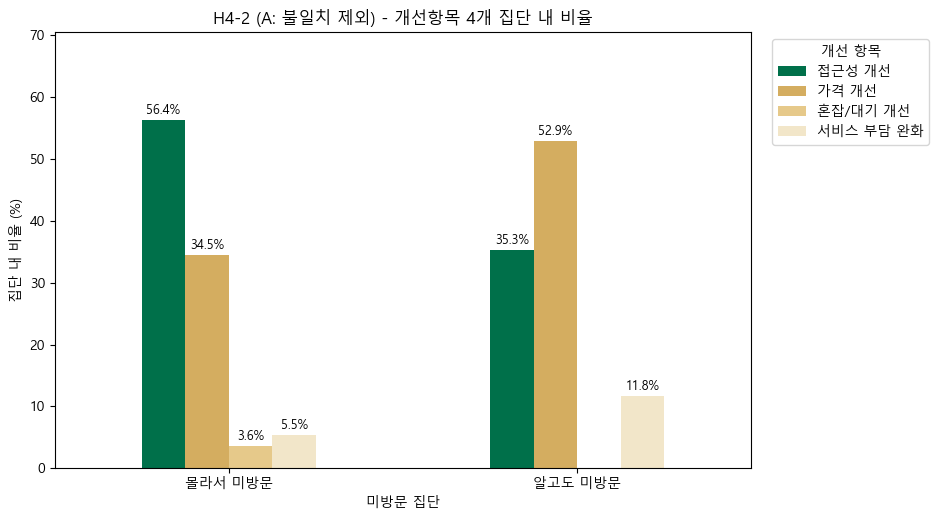

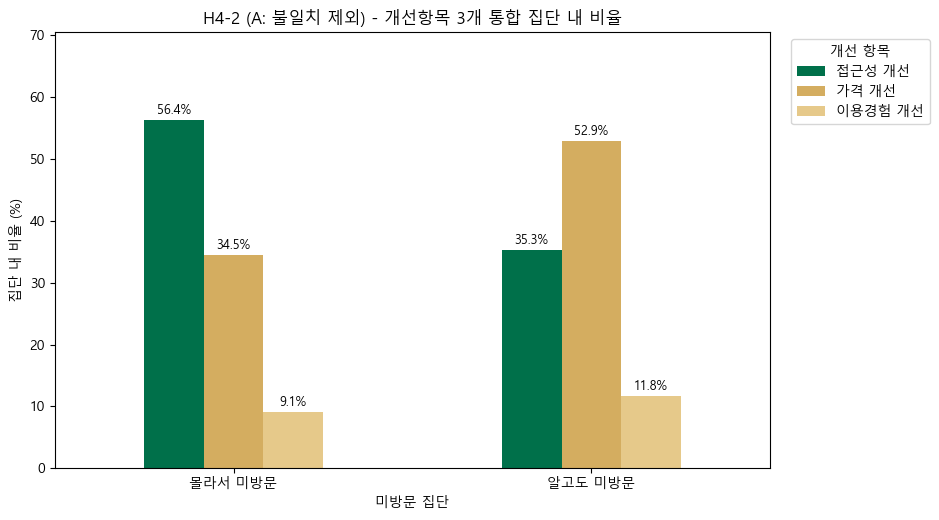

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

# 한글 폰트(혹시 필요)
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

STARBUCKS_GREEN = "#00704A"
GOLD_1 = "#D4AD60"  # 진한 금
GOLD_2 = "#E6C98A"  # 중간 금(연함)
GOLD_3 = "#F2E6C9"  # 연한 베이지

def plot_ct_pct_starbucks_palette(ct_pct, title="집단 내 개선항목 비율(스타벅스 톤)"):
    """
    - 색은 '개선항목(컬럼)' 기준으로 고정(두번째 사진처럼 구분 잘 됨)
    - 1위로 강조하고 싶은 항목(접근성 개선)을 초록으로 고정
    - 나머지는 금 계열 톤으로 고정 (막대 단색, 혼합/그라데이션 없음)
    - 범례에는 개선항목과 해당 색이 그대로 반영됨
    """
    data = ct_pct.copy().astype(float)

    # 컬럼 순서를 유지한 채 색을 매핑
    cols = list(data.columns)

    # 기본 팔레트(4개 기준). 3개면 자동으로 앞에서부터 사용.
    color_map = {
        "접근성 개선": STARBUCKS_GREEN,   # 초록(핵심 강조)
        "가격 개선": GOLD_1,
        "혼잡/대기 개선": GOLD_2,
        "서비스 부담 완화": GOLD_3,
        "이용경험 개선": GOLD_2,  # 3개 통합일 때 사용
    }
    colors = [color_map.get(c, GOLD_1) for c in cols]

    ax = data.plot(kind="bar", figsize=(9.5, 5.3), rot=0, color=colors)

    plt.title(title)
    plt.xlabel("미방문 집단")
    plt.ylabel("집단 내 비율 (%)")
    plt.legend(title="개선 항목", bbox_to_anchor=(1.02, 1), loc="upper left")

    # 라벨(퍼센트)
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(f"{h:.1f}%",
                        (p.get_x() + p.get_width()/2, h),
                        ha="center", va="bottom", fontsize=9,
                        xytext=(0, 2), textcoords="offset points")

    # y축 여백
    ymax = data.max().max()
    ax.set_ylim(0, ymax * 1.25 if ymax > 0 else 1)

    plt.tight_layout()
    plt.show()


# ===== 실행 =====
plot_ct_pct_starbucks_palette(res_A_4["ct_pct"], title="H4-2 (A: 불일치 제외) - 개선항목 4개 집단 내 비율")
plot_ct_pct_starbucks_palette(res_A_3["ct_pct"], title="H4-2 (A: 불일치 제외) - 개선항목 3개 통합 집단 내 비율")

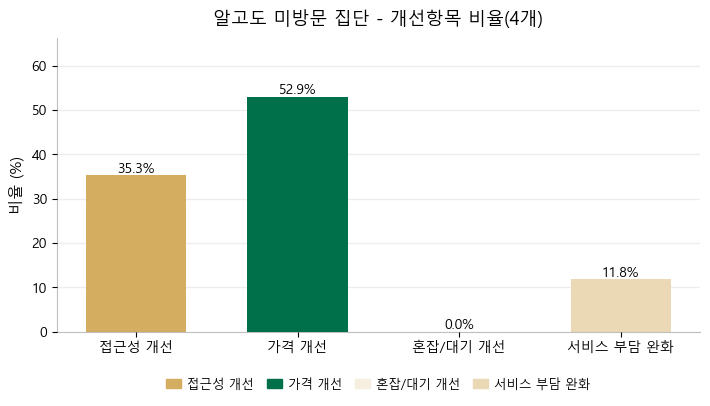

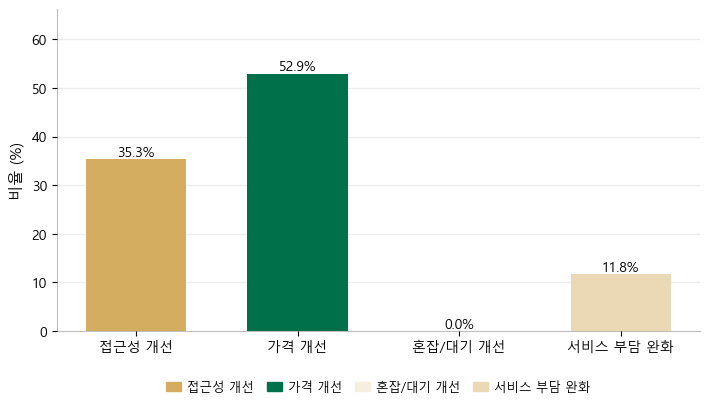

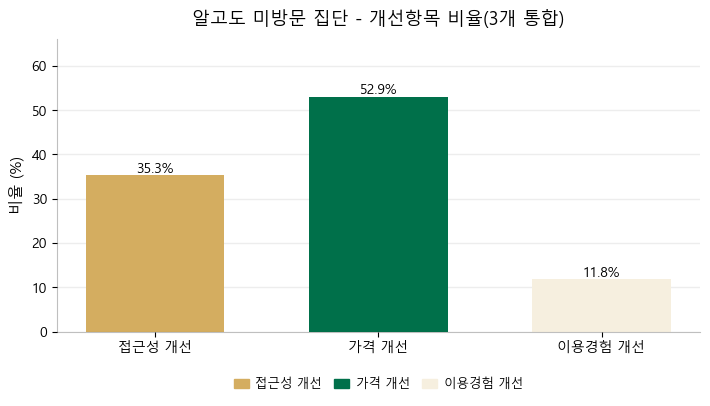

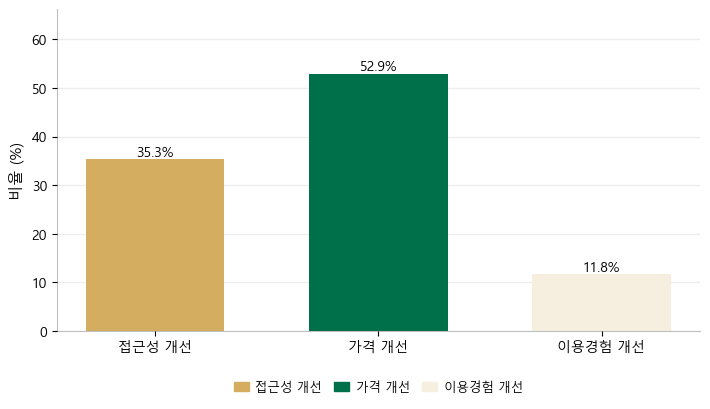

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import platform

# =========================================
# 공통 스타일(폰트/색)
# =========================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

STARBUCKS_GREEN = "#00704A"
STARBUCKS_GOLD  = "#D4AD60"

def blend_with_white(hex_color, t):
    """
    t: 0~1
    - 0이면 거의 흰색(아주 연함)
    - 1이면 원래 색(진함)
    """
    rgb = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1, 1, 1])
    return white * (1 - t) + rgb * t

def plot_known_nonvisit_improvements_dynamic(
    ct_pct,
    group_name="알고도 미방문",
    title=None,                    # None이면 제목 없음
    items_order=None,              # None이면 기본 4개/3개 자동 처리
    figsize=(7.2, 4.2),
    bar_width=0.62,
    grid_alpha=0.22,
    legend_fontsize=9,
    gold_min_t=0.20,               # 골드 밝기 하한(작을수록 더 연해짐)
    gold_max_t=1.00                # 골드 진하기 상한(1.0=원래 골드)
):
    """
    요구사항 반영:
    1) '제일 높은 비율' 막대 1개만 초록
    2) 나머지는 동일 골드(#D4AD60) 기반으로 비율이 높을수록 진하게(흰색 블렌딩으로 농도 조절)
    3) 어떤 항목이 아예 없어도(컬럼이 없거나 값이 NaN) items_order 기준으로 0% 포함해서 표시
    4) 배경 투명 + y축 가로 gridline 희미하게 + 범례 작고 깔끔
    5) x축 라벨(미방문 집단 문구) 없음
    """

    # 기본 표시 항목(4개 버전 기준). 3개 통합이면 items_order를 아래처럼 넘겨주면 됨.
    if items_order is None:
        items_order = ["접근성 개선", "가격 개선", "혼잡/대기 개선", "서비스 부담 완화"]

    if group_name not in ct_pct.index:
        raise KeyError(f"ct_pct.index에 '{group_name}'가 없습니다. 현재 index: {list(ct_pct.index)}")

    # 0% 포함해서 강제로 컬럼 맞추기 (없으면 0으로 채움)
    s = ct_pct.loc[group_name].astype(float)
    s = s.reindex(items_order, fill_value=0.0).fillna(0.0)

    items = list(s.index)
    vals = s.values.astype(float)

    # ---- 1등(최대값) 찾기: 동률이면 첫 번째를 초록 ----
    imax = int(np.argmax(vals))

    # ---- 나머지 골드 농도(밝기) 계산: 값이 높을수록 진하게 ----
    other_idx = [i for i in range(len(vals)) if i != imax]
    other_vals = vals[other_idx] if len(other_idx) > 0 else np.array([])

    colors = []
    for i, v in enumerate(vals):
        if i == imax:
            colors.append(STARBUCKS_GREEN)
        else:
            if len(other_vals) == 0:
                t = gold_max_t
            else:
                vmin, vmax = float(other_vals.min()), float(other_vals.max())
                if vmax == vmin:
                    t = gold_max_t  # 다 같으면 동일 진하기
                else:
                    z = (v - vmin) / (vmax - vmin)            # 0~1
                    t = gold_min_t + (gold_max_t - gold_min_t) * float(z)  # gold_min_t~gold_max_t
            colors.append(blend_with_white(STARBUCKS_GOLD, t))

    # ---- Figure/Axes(배경 투명) ----
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    x = np.arange(len(items))
    bars = ax.bar(x, vals, width=bar_width, color=colors)

    # ---- y축 gridline(희미) ----
    ax.yaxis.grid(True, linestyle="-", linewidth=1, alpha=grid_alpha)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    # ---- 제목 옵션 ----
    if title is not None and str(title).strip() != "":
        ax.set_title(title, fontsize=13, pad=10)

    # ---- 축/틱 ----
    ax.set_xlabel("")  # “미방문 집단” 문구 제거
    ax.set_ylabel("비율 (%)", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(items, fontsize=10)

    # ---- y축 범위(라벨 공간 확보) ----
    ymax = float(np.max(vals)) if len(vals) else 1.0
    ax.set_ylim(0, ymax * 1.25 if ymax > 0 else 1)

    # ---- 값 라벨: 0%도 표시 ----
    for b, v in zip(bars, vals):
        ax.text(
            b.get_x() + b.get_width() / 2,
            v if v > 0 else 0,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

    # ---- 범례(색 반영: 1등=초록, 나머지=골드 농도) ----
    handles = [mpatches.Patch(color=colors[i], label=items[i]) for i in range(len(items))]
    ax.legend(
        handles=handles,
        frameon=False,
        fontsize=legend_fontsize,
        ncol=min(len(items), 4),
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        handlelength=1.2,
        handletextpad=0.5,
        columnspacing=1.0
    )

    # ---- 스파인 최소화 ----
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

    plt.tight_layout()
    plt.show()


# =========================================
# 실행 예시 (알고도 미방문만)
# - 4개 항목 / 3개 통합 항목 모두 0% 포함 표시
# - 제목 있는 버전/없는 버전 2개
# =========================================

# --- 4개 개선항목 버전 ---
items_4 = ["접근성 개선", "가격 개선", "혼잡/대기 개선", "서비스 부담 완화"]

plot_known_nonvisit_improvements_dynamic(
    res_A_4["ct_pct"],
    group_name="알고도 미방문",
    items_order=items_4,
    title="알고도 미방문 집단 - 개선항목 비율(4개)"
)

plot_known_nonvisit_improvements_dynamic(
    res_A_4["ct_pct"],
    group_name="알고도 미방문",
    items_order=items_4,
    title=None
)

# --- 3개 통합 버전 ---
items_3 = ["접근성 개선", "가격 개선", "이용경험 개선"]

plot_known_nonvisit_improvements_dynamic(
    res_A_3["ct_pct"],
    group_name="알고도 미방문",
    items_order=items_3,
    title="알고도 미방문 집단 - 개선항목 비율(3개 통합)"
)

plot_known_nonvisit_improvements_dynamic(
    res_A_3["ct_pct"],
    group_name="알고도 미방문",
    items_order=items_3,
    title=None
)

✅ [알고도 미방문] 표본 수 n = 17명


,건수,비율(%)
improve_grouped,,
접근성 개선,6,35.3
가격 개선,9,52.9
혼잡/대기 개선,0,0.0
서비스 부담 완화,2,11.8


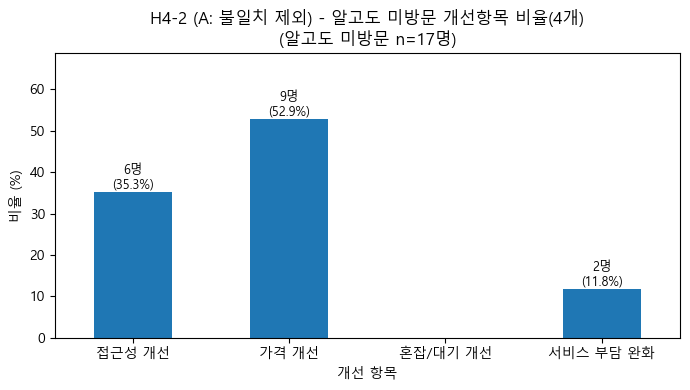

✅ [알고도 미방문] 표본 수 n = 17명


,건수,비율(%)
improve_grouped_3,,
접근성 개선,6,35.3
가격 개선,9,52.9
이용경험 개선,2,11.8


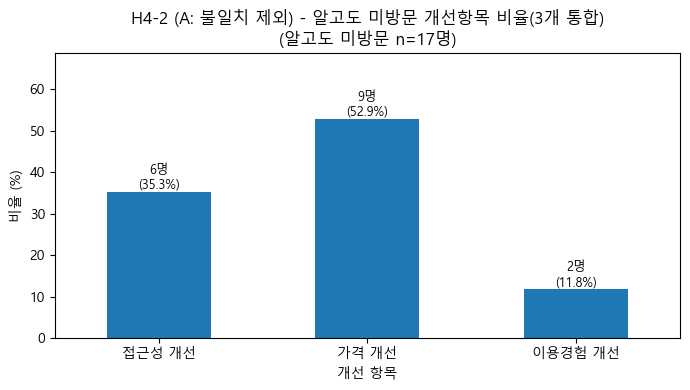

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def compute_and_plot_group_only(df_in, group_name="알고도 미방문", col="improve_grouped",
                                col_order=None, title="알고도 미방문 - 개선항목 분포"):
    # 1) 특정 집단만 필터링
    d = df_in[df_in["h4_group"] == group_name].copy()
    d = d.dropna(subset=[col])

    # 표본 수 (몇 명인지)
    n_group = len(d)

    # 2) 건수/비율 계산
    ct = d[col].value_counts()
    pct = (ct / ct.sum() * 100).round(1)

    # 순서 지정
    if col_order is not None:
        ct = ct.reindex(col_order, fill_value=0)
        pct = pct.reindex(col_order, fill_value=0)

    # 3) 표 출력 (건수/비율 + 집단 n)
    print(f"✅ [{group_name}] 표본 수 n = {n_group}명")
    display(pd.DataFrame({"건수": ct, "비율(%)": pct}))

    # 4) 그래프
    ax = pct.plot(kind="bar", figsize=(7,4), rot=0)

    # 제목에 n 포함
    plt.title(f"{title}\n({group_name} n={n_group}명)")
    plt.xlabel("개선 항목")
    plt.ylabel("비율 (%)")

    ymax = pct.max()
    ax.set_ylim(0, ymax * 1.30 if ymax > 0 else 1)

    # ✅ 라벨: "건수명 (퍼센트%)" 같이 표시
    for i, (v_pct, v_cnt) in enumerate(zip(pct.values, ct.values)):
        if pd.notna(v_pct) and v_pct > 0:
            ax.text(
                i, v_pct,
                f"{int(v_cnt)}명\n({v_pct:.1f}%)",
                ha="center", va="bottom", fontsize=9
            )

    plt.tight_layout()
    plt.show()

# ----------------------------
# 실행 (너가 쓰던 그대로)
# ----------------------------

# 4개 개선항목: nv_A 기준(불일치 제외)에서 알고도 미방문만
order_4 = ["접근성 개선", "가격 개선", "혼잡/대기 개선", "서비스 부담 완화"]
compute_and_plot_group_only(
    nv_A,
    group_name="알고도 미방문",
    col="improve_grouped",
    col_order=order_4,
    title="H4-2 (A: 불일치 제외) - 알고도 미방문 개선항목 비율(4개)"
)

# 3개 통합 항목
nv_A_3 = nv_A.copy()
nv_A_3["improve_grouped_3"] = nv_A_3["improve_grouped"].replace({
    "혼잡/대기 개선": "이용경험 개선",
    "서비스 부담 완화": "이용경험 개선"
})
order_3 = ["접근성 개선", "가격 개선", "이용경험 개선"]

compute_and_plot_group_only(
    nv_A_3,
    group_name="알고도 미방문",
    col="improve_grouped_3",
    col_order=order_3,
    title="H4-2 (A: 불일치 제외) - 알고도 미방문 개선항목 비율(3개 통합)"
)

In [ ]:
# =========================================
# H4-2 시각화: 집단 내 비율 막대그래프
# =========================================

def plot_ct_pct(ct_pct, title="집단 내 개선항목 비율"):
    ax = ct_pct.plot(kind="bar", figsize=(9, 5), rot=0)
    plt.title(title)
    plt.xlabel("미방문 집단")
    plt.ylabel("집단 내 비율 (%)")
    plt.legend(title="개선 항목", bbox_to_anchor=(1.02, 1), loc="upper left")

    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(
                f"{h:.1f}%",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom", fontsize=8,
                xytext=(0, 2), textcoords="offset points"
            )

    plt.tight_layout()
    plt.show()

# 4개 버전 시각화(A)
plot_ct_pct(res_A_4["ct_pct"], title="H4-2 (A: 불일치 제외) - 개선항목 4개 집단 내 비율")

# 3개 통합 버전 시각화(A)
plot_ct_pct(res_A_3["ct_pct"], title="H4-2 (A: 불일치 제외) - 개선항목 3개 통합 집단 내 비율")

✅ 셀 5. “불일치 2건” 처리 결과를 보고서에 어떻게 쓰면 좋나? (문장 템플릿)

보고서/발표에서 가장 깔끔한 방식은 이거야:

**기본 분석(A: 불일치 제외)**을 메인으로 제시

**민감도(C: 이유 우선 재분류)**를 한 줄로만 추가해서 “결론이 흔들리지 않음”을 보여주기

아래 문장 그대로 써도 돼:

“인지=예이면서 미방문 이유가 ‘몰랐음’으로 응답된 2건의 불일치 응답이 존재하였다. 본 분석에서는 정의의 일관성을 위해 해당 2건을 제외(A)하여 주 분석을 수행하였고, 추가로 ‘이유 우선’ 규칙으로 재분류(C)한 민감도 분석을 병행하였다. 두 처리 방식 모두에서 결과 해석 방향이 크게 달라지지 않음을 확인하였다.”

In [12]:
import numpy as np
import pandas as pd

def summarize_h4_2(res_obj, title="H4-2", alpha=0.05, resid_cut=2.0):
    ct = res_obj["ct"]
    ct_pct = res_obj["ct_pct"]

    # ✅ 키가 없을 수 있는 값들은 get()으로 안전하게
    p = float(res_obj.get("p", np.nan))
    chi2 = float(res_obj.get("chi2", np.nan))

    expected = res_obj.get("expected", None)
    std_resid = res_obj.get("std_resid", None)

    # ✅ dof 없으면 교차표 shape로 계산: (r-1)*(c-1)
    dof = res_obj.get("dof", None)
    if dof is None:
        dof = int((ct.shape[0] - 1) * (ct.shape[1] - 1))
    else:
        dof = int(dof)

    # ✅ expected / std_resid 없으면 여기서 만들어도 됨(있으면 그대로 사용)
    if expected is None or std_resid is None:
        # 기대도수 계산(독립 가정)
        row_sum = ct.sum(axis=1).values.reshape(-1, 1)
        col_sum = ct.sum(axis=0).values.reshape(1, -1)
        total = ct.values.sum()
        exp = (row_sum @ col_sum) / total
        expected = pd.DataFrame(exp, index=ct.index, columns=ct.columns)

        # 표준화 잔차 (관측-기대)/sqrt(기대)
        std_resid = (ct - expected) / np.sqrt(expected)
        std_resid = std_resid.replace([np.inf, -np.inf], np.nan)

    print("="*80)
    print(f"[자동 해석] {title}")
    print("="*80)

    # 1) 유의성 결론 (p가 없으면 안내)
    if np.isnan(p):
        print("⚠️ p-value 정보가 res_obj에 없어 유의성 결론을 자동으로 낼 수 없습니다.")
        print(f"   (chi2={chi2:.2f}, dof={dof})")
    else:
        if p < alpha:
            print(f"✅ 카이제곱 독립성 검정 결과, 두 집단의 개선항목 분포는 유의하게 다릅니다.")
            print(f"   (chi2={chi2:.2f}, dof={dof}, p={p:.6f})")
        else:
            print(f"❌ 카이제곱 독립성 검정 결과, 두 집단의 개선항목 분포 차이는 유의하다고 보기 어렵습니다.")
            print(f"   (chi2={chi2:.2f}, dof={dof}, p={p:.6f})")
            print("   ※ 다만 아래 패턴은 탐색적(참고용)으로 해석할 수 있습니다.")

    # 2) 집단별 Top 개선항목(비율 기준)
    print("\n[집단별 개선항목 Top]")
    for grp in ct_pct.index:
        top_item = ct_pct.loc[grp].idxmax()
        top_val = ct_pct.loc[grp].max()
        print(f"- {grp}: '{top_item}' 비중이 가장 큼 ({top_val:.1f}%)")

    # 3) 표준화 잔차 기반 핵심 차이 셀 찾기
    flagged = []
    for r in std_resid.index:
        for c in std_resid.columns:
            val = float(std_resid.loc[r, c])
            if pd.notna(val) and abs(val) >= resid_cut:
                flagged.append((r, c, val, int(ct.loc[r, c]), float(expected.loc[r, c])))

    print("\n[차이를 만든 셀(표준화 잔차 |resid| >= {:.1f})]".format(resid_cut))
    if len(flagged) == 0:
        print("- 해당 기준을 넘는 셀이 없습니다. (차이가 특정 셀에 강하게 몰리지 않았을 수 있음)")
    else:
        flagged = sorted(flagged, key=lambda x: abs(x[2]), reverse=True)
        for r, c, resid, obs, exp in flagged:
            direction = "기대보다 큼(과대표집)" if resid > 0 else "기대보다 작음(과소대표집)"
            print(f"- [{r} × {c}] resid={resid:.2f} → {direction} | 관측={obs}, 기대={exp:.1f}")

    # 4) 발표/보고서용 한 문단 자동 생성
    print("\n[보고서/발표용 요약 문단(자동 생성)]")

    if np.isnan(p):
        sentence = (
            f"{title} 분석에서 두 집단의 개선 필요 항목 분포 차이에 대해 "
            f"자동 유의성 판단(p-value)이 불가했으나, 교차표 비율 패턴을 기준으로 해석을 제시한다. "
        )
    elif p < alpha:
        sentence = (
            f"{title} 분석에서 ‘몰라서 미방문’ 집단과 ‘알고도 미방문’ 집단의 개선 필요 항목 분포는 "
            f"통계적으로 유의하게 달랐다(χ²={chi2:.2f}, p={p:.6f}). "
        )
    else:
        sentence = (
            f"{title} 분석에서 ‘몰라서 미방문’ 집단과 ‘알고도 미방문’ 집단의 개선 필요 항목 분포 차이는 "
            f"통계적으로 유의하다고 보기 어려웠다(χ²={chi2:.2f}, p={p:.6f}). "
        )

    grpA, grpB = ct_pct.index[0], ct_pct.index[1]
    topA, valA = ct_pct.loc[grpA].idxmax(), ct_pct.loc[grpA].max()
    topB, valB = ct_pct.loc[grpB].idxmax(), ct_pct.loc[grpB].max()

    sentence += (
        f"비율 기준으로는 {grpA}에서 '{topA}'가 가장 높은 비중({valA:.1f}%)을 보였고, "
        f"{grpB}에서는 '{topB}'가 가장 높은 비중({valB:.1f}%)을 보였다."
    )

    if len(flagged) > 0:
        r, c, resid, obs, exp = flagged[0]
        sentence += (
            f" 표준화 잔차 기준으로는 [{r}×{c}]에서 관측값이 기대값 대비 "
            f"{'높게' if resid > 0 else '낮게'} 나타나(잔차={resid:.2f}) 집단 간 차이에 기여했다."
        )

    print(sentence)
    print("\n※ 주의: 표준화 잔차 해석은 기대빈도가 충분할 때 더 안정적이며, 표본이 작을 경우 탐색적으로 해석하세요.")

# -----------------------------------------
# 실행 예시
# - 앞에서 만든 res_A_4 / res_A_3 중 원하는 걸 넣으면 됨
# -----------------------------------------
summarize_h4_2(res_A_4, title="H4-2 (개선항목 4개)", alpha=0.05, resid_cut=2.0)
summarize_h4_2(res_A_3, title="H4-2 (개선항목 3개 통합)", alpha=0.05, resid_cut=2.0)

[자동 해석] H4-2 (개선항목 4개)
❌ 카이제곱 독립성 검정 결과, 두 집단의 개선항목 분포 차이는 유의하다고 보기 어렵습니다.
   (chi2=3.61, dof=3, p=0.306199)
   ※ 다만 아래 패턴은 탐색적(참고용)으로 해석할 수 있습니다.

[집단별 개선항목 Top]
- 몰라서 미방문: '접근성 개선' 비중이 가장 큼 (56.4%)
- 알고도 미방문: '가격 개선' 비중이 가장 큼 (52.9%)

[차이를 만든 셀(표준화 잔차 |resid| >= 2.0)]
- 해당 기준을 넘는 셀이 없습니다. (차이가 특정 셀에 강하게 몰리지 않았을 수 있음)

[보고서/발표용 요약 문단(자동 생성)]
H4-2 (개선항목 4개) 분석에서 ‘몰라서 미방문’ 집단과 ‘알고도 미방문’ 집단의 개선 필요 항목 분포 차이는 통계적으로 유의하다고 보기 어려웠다(χ²=3.61, p=0.306199). 비율 기준으로는 몰라서 미방문에서 '접근성 개선'가 가장 높은 비중(56.4%)을 보였고, 알고도 미방문에서는 '가격 개선'가 가장 높은 비중(52.9%)을 보였다.

※ 주의: 표준화 잔차 해석은 기대빈도가 충분할 때 더 안정적이며, 표본이 작을 경우 탐색적으로 해석하세요.
[자동 해석] H4-2 (개선항목 3개 통합)
❌ 카이제곱 독립성 검정 결과, 두 집단의 개선항목 분포 차이는 유의하다고 보기 어렵습니다.
   (chi2=2.35, dof=2, p=0.309232)
   ※ 다만 아래 패턴은 탐색적(참고용)으로 해석할 수 있습니다.

[집단별 개선항목 Top]
- 몰라서 미방문: '접근성 개선' 비중이 가장 큼 (56.4%)
- 알고도 미방문: '가격 개선' 비중이 가장 큼 (52.9%)

[차이를 만든 셀(표준화 잔차 |resid| >= 2.0)]
- 해당 기준을 넘는 셀이 없습니다. (차이가 특정 셀에 강하게 몰리지 않았을 수 있음)

[보고서/발표용 요약 문단(자동 생성)]
H4-2 (개선항목 3개 통합) 분석에서 ‘몰라서 미방문’ 집단과 ‘알고도 미방문’